In [1]:
from pipeline_preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]

Nombre de lignes complètement vides : 0


In [2]:
cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

cols_tsq_PD = df_TSQ_PD.columns[0:40]
df_PD = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_PD, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df_PD[items] = df_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# retester les modeles d'embedding sans les var TSQ = df_red

In [3]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red = df.drop(columns=colonnes_a_exclure)
len(df_red.columns)  # Vérifie le nombre de colonnes restantes
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40'],
      dtype='str')


In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

from sklearn.preprocessing import StandardScaler    

# on ne standardise pas car les données ston sur la mm echelle 0-10
X = df_red.values 
perplexity = np.arange(5, 55, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    reduced = model.fit_transform(X)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show(renderer="browser")

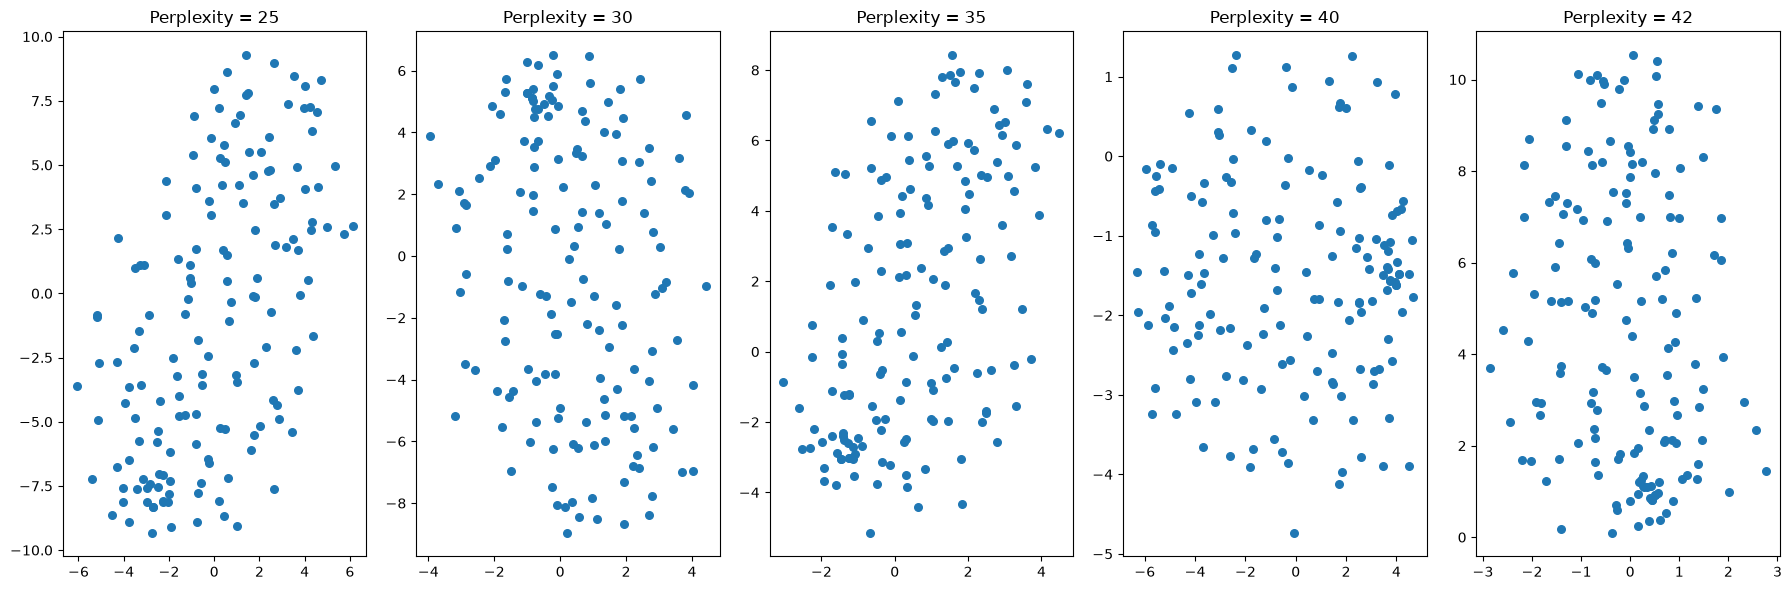

In [5]:
import matplotlib.pyplot as plt

perplexities_to_test = [25, 30, 35, 40, 42]
fig, axes = plt.subplots(1, len(perplexities_to_test), figsize=(18, 6))

for ax, p in zip(axes, perplexities_to_test):
    model = TSNE(n_components=2, init="pca", perplexity=p, random_state=42) #hyperpara : init, generalement "random" mais ici c'est plus  en faisant pca
    reduced = model.fit_transform(X)
    ax.scatter(reduced[:, 0], reduced[:, 1], s=30)
    ax.set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X)

tsne.kl_divergence_

0.31720080971717834

In [7]:
participant_ids = df_red.index  # [0, 1, 2, ..., 153]
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1])

fig.update_layout(
    title="t-SNE visualization - Participants sains",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)  # essaie différents n_clusters
clusters = kmeans.fit_predict(X)
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig = px.scatter(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hover_name=participant_ids,
    color=clusters.astype(str),  # colore par cluster trouvé
    color_discrete_sequence=custom_colors
)
fig.update_layout(
    title="t-SNE coloré par clusters KMeans",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")
# donne un graph interactif en cliquant sur les points : on sait qui est le aprticipant

In [30]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import plotly.express as px
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 

# TSNE en 3 dimensions
tsne = TSNE(n_components=3, perplexity=45, random_state=42)
projections = tsne.fit_transform(X)

# Clustering pour avoir une couleur (puisque tu n'as pas de labels)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

fig = px.scatter_3d(
    projections, x=0, y=1, z=2,
    color=clusters.astype(str),
    labels={'color': 'Cluster'},
    hover_name=[f"Participant {i}" for i in df.index],
    color_discrete_sequence=custom_colors
)
fig.update_traces(marker_size=5)
fig.update_layout(title="t-SNE 3D - Participants sains (TSQ)")
fig.show(renderer="browser")

# faire silhouette clustering --> trouver combien k doit etre egal

si tu clusterises directement sur les valeurs brutes des items, la variance dominante dans tes données, c'est le niveau général (quelqu'un qui répond "8/10" partout vs quelqu'un qui répond "2/10" partout). Le clustering va donc naturellement regrouper les gens par sévérité globale, écrasant les différences de profil (qui répond fort sur l'anxiété mais faible sur le retrait social, par exemple).

Pour capturer des profils/types de symptômes plutôt que la sévérité, il faut retirer l'effet du niveau global avant de clusteriser. Plusieurs approches, de la plus simple à la plus poussée :

In [10]:
cols_tsq_brutes = df_red.columns[0:33]
df_red = df_red.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 34)])))
items = [f"TSQ{i}" for i in range(1, 34)]
df_red[items] = df_red[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
X = df_red[items].values

# Vérification
print("Nombre de participants :", X.shape[0])
print("Nombre d'items :", X.shape[1])


Nombre de participants : 154
Nombre d'items : 33


Nombre de participants : 154
Nombre d'items : 33
k=2: silhouette = 0.319
k=3: silhouette = 0.220
k=4: silhouette = 0.138
k=5: silhouette = 0.157
k=6: silhouette = 0.146
k=7: silhouette = 0.122
k=8: silhouette = 0.136
k=9: silhouette = 0.107
k=10: silhouette = 0.121


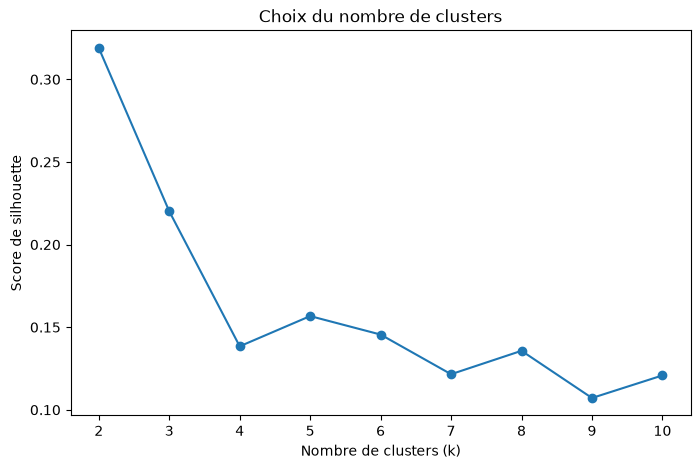


Meilleur k selon le score de silhouette : 2
Score de silhouette : 0.319


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X = df_red[items].values

# Vérification
print("Nombre de participants :", X.shape[0])
print("Nombre d'items :", X.shape[1])


k_values = range(2, 11) #on teste pls nb de clusters
scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    scores.append(score)
    
    print(f"k={k}: silhouette = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters")
plt.xticks(list(k_values))
plt.show()


best_k = k_values[np.argmax(scores)]

print(f"\nMeilleur k selon le score de silhouette : {best_k}")
print(f"Score de silhouette : {max(scores):.3f}")

lire l’indice de silhouette :

Proche de 1 : les points sont bien à l’intérieur de leurs clusters et loin des autres
Autour de 0,7 : bon clustering, groupes distincts et points proches de leurs pairs dans le cluster
Autour de 0,5 : clustering correct, avec un certain chevauchement mais des groupes encore différenciables
Près de 0 : clusters qui se chevauchent ou frontières floues. La structure perçue peut être illusoire
En dessous de 0 : les points sont plus proches d’un mauvais cluster. Cela peut arriver si vous choisissez un mauvais nombre de clusters ou si les données se prêtent mal au clustering.

# tester autres metho : méthode du coude, indice de Davies-Bouldin, indice de Calinski-Harabasz --> regarder sur https://www.datacamp.com/fr/tutorial/silhouette-score

k=2 | inertie=23881.7 | silhouette=0.319 | davies-bouldin=1.459 | calinski-harabasz=67.0
k=3 | inertie=21866.5 | silhouette=0.220 | davies-bouldin=2.160 | calinski-harabasz=43.3
k=4 | inertie=20686.0 | silhouette=0.138 | davies-bouldin=2.485 | calinski-harabasz=33.2
k=5 | inertie=19770.2 | silhouette=0.157 | davies-bouldin=2.369 | calinski-harabasz=27.6
k=6 | inertie=19422.2 | silhouette=0.146 | davies-bouldin=2.337 | calinski-harabasz=22.8
k=7 | inertie=18899.4 | silhouette=0.122 | davies-bouldin=2.678 | calinski-harabasz=20.1
k=8 | inertie=18109.4 | silhouette=0.136 | davies-bouldin=2.415 | calinski-harabasz=18.8
k=9 | inertie=17747.3 | silhouette=0.107 | davies-bouldin=2.422 | calinski-harabasz=17.0
k=10 | inertie=17559.9 | silhouette=0.121 | davies-bouldin=2.408 | calinski-harabasz=15.3


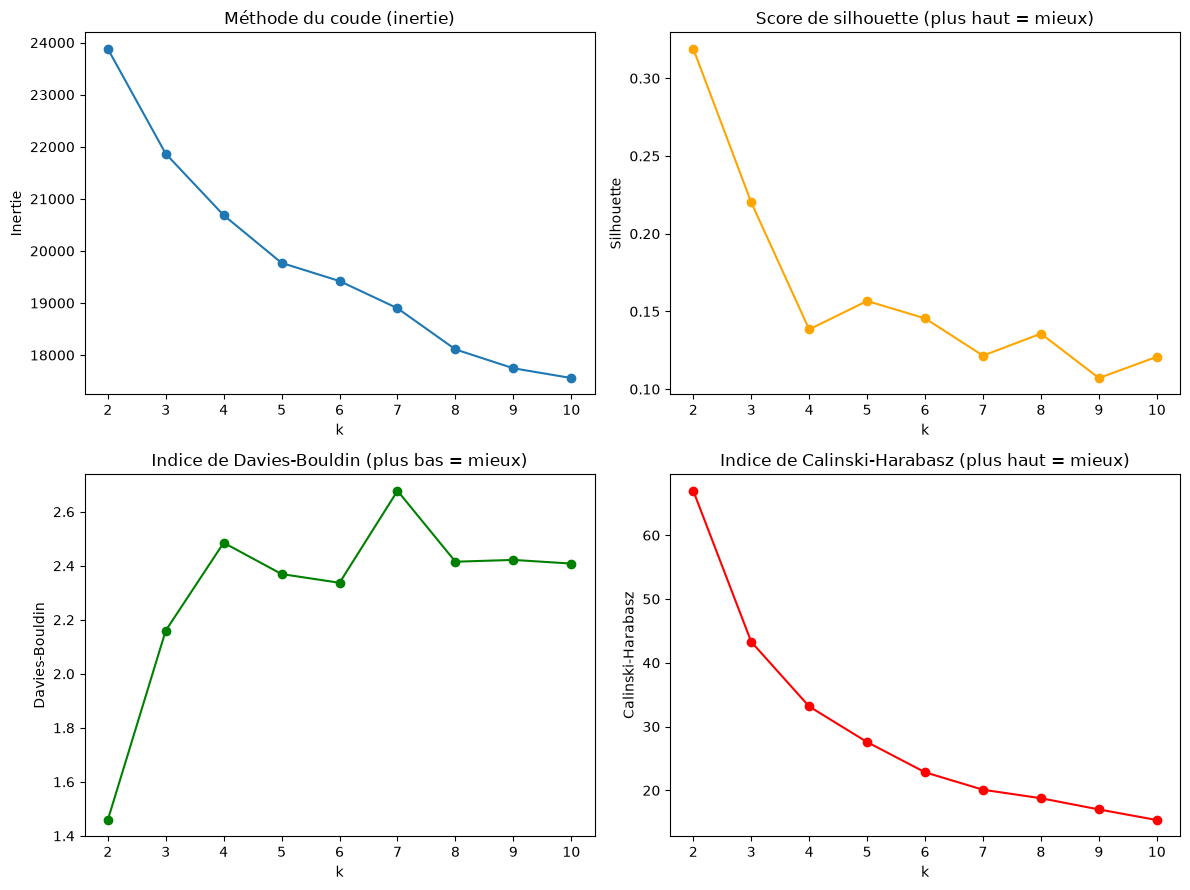


Meilleur k selon chaque indice :
  Silhouette (max)        : k=2 (score=0.319)
  Davies-Bouldin (min)    : k=2 (score=1.459)
  Calinski-Harabasz (max) : k=2 (score=67.0)


,k,inertie,silhouette,davies_bouldin,calinski_harabasz
0,2,23881.724490,0.318968,1.458715,66.969221
1,3,21866.480808,0.220152,2.160158,43.288180
2,4,20685.994098,0.138431,2.485332,33.156993
3,5,19770.242424,0.156723,2.369484,27.571556
4,6,19422.159228,0.145533,2.337140,22.832356
5,7,18899.416667,0.121542,2.677739,20.098767
6,8,18109.435712,0.135711,2.415142,18.766561
7,9,17747.260289,0.107147,2.421828,17.010963
8,10,17559.900519,0.120802,2.408248,15.347514


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X = df_red[items].values  # même jeu de données que pour le score de silhouette

k_values = range(2, 11)
inerties = []
silhouettes = []
davies_bouldin = []
calinski_harabasz = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))
    calinski_harabasz.append(calinski_harabasz_score(X, labels))

    print(f"k={k} | inertie={kmeans.inertia_:.1f} | silhouette={silhouettes[-1]:.3f} "
          f"| davies-bouldin={davies_bouldin[-1]:.3f} | calinski-harabasz={calinski_harabasz[-1]:.1f}")

# Récapitulatif dans un tableau
resultats_k = pd.DataFrame({
    "k": list(k_values),
    "inertie": inerties,
    "silhouette": silhouettes,
    "davies_bouldin": davies_bouldin,
    "calinski_harabasz": calinski_harabasz,
})

# Visualisation des 4 indices côte à côte
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(k_values, inerties, marker="o")
axes[0, 0].set_title("Méthode du coude (inertie)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertie")

axes[0, 1].plot(k_values, silhouettes, marker="o", color="orange")
axes[0, 1].set_title("Score de silhouette (plus haut = mieux)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Silhouette")

axes[1, 0].plot(k_values, davies_bouldin, marker="o", color="green")
axes[1, 0].set_title("Indice de Davies-Bouldin (plus bas = mieux)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Davies-Bouldin")

axes[1, 1].plot(k_values, calinski_harabasz, marker="o", color="red")
axes[1, 1].set_title("Indice de Calinski-Harabasz (plus haut = mieux)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Calinski-Harabasz")

for ax in axes.flat:
    ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

# Meilleur k selon chaque indice
print("\nMeilleur k selon chaque indice :")
print(f"  Silhouette (max)        : k={resultats_k.loc[resultats_k['silhouette'].idxmax(), 'k']} "
      f"(score={resultats_k['silhouette'].max():.3f})")
print(f"  Davies-Bouldin (min)    : k={resultats_k.loc[resultats_k['davies_bouldin'].idxmin(), 'k']} "
      f"(score={resultats_k['davies_bouldin'].min():.3f})")
print(f"  Calinski-Harabasz (max) : k={resultats_k.loc[resultats_k['calinski_harabasz'].idxmax(), 'k']} "
      f"(score={resultats_k['calinski_harabasz'].max():.1f})")

resultats_k

# ou alors Distance de corrélation plutôt qu'euclidienne

Une autre manière de dire la même chose : au lieu de mesurer la distance euclidienne entre deux participants (sensible au niveau absolu), utiliser une distance basée sur la corrélation entre leurs profils de réponses — deux personnes avec des patterns similaires mais des niveaux différents auront une distance faible.

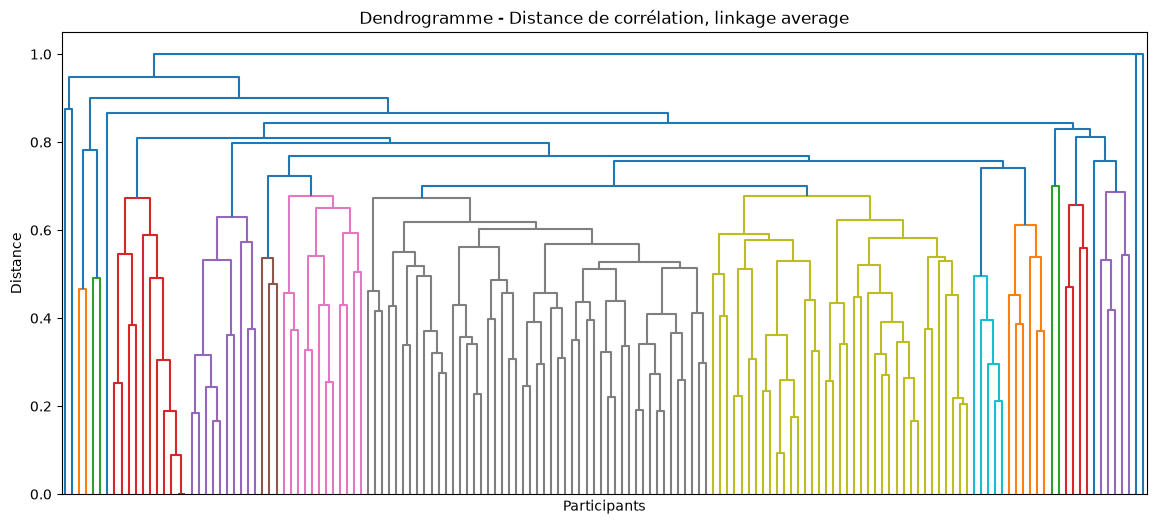

k=2: silhouette = 0.242
k=3: silhouette = 0.242
k=4: silhouette = 0.182
k=5: silhouette = 0.125
k=6: silhouette = 0.073
k=7: silhouette = 0.000
k=8: silhouette = 0.004
k=9: silhouette = -0.006
k=10: silhouette = -0.017


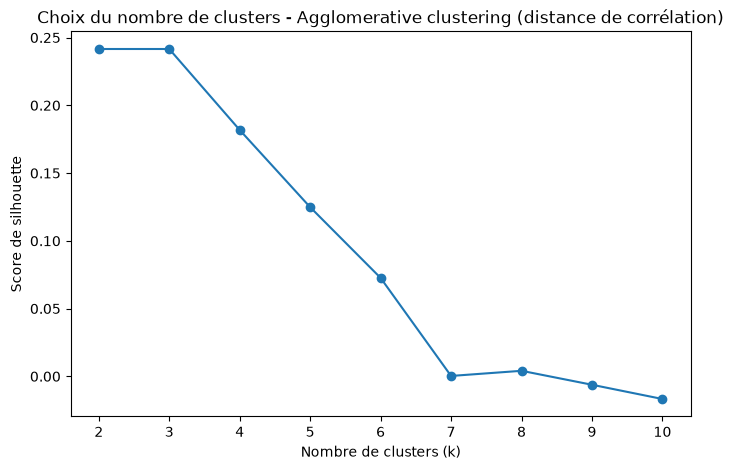


Meilleur k selon le score de silhouette : 2
Score de silhouette : 0.242


cluster
1    152
0      2
Name: count, dtype: int64

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform, correlation as corr_metric
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

def distance_corr_safe(u, v):
    # Corrélation indéfinie si un profil est constant (variance nulle)
    # -> on assigne une distance de 1 (équivalent à une corrélation nulle),
    #    ce qui est la convention la plus neutre : on ne suppose ni ressemblance ni opposition
    if np.std(u) == 0 or np.std(v) == 0:
        return 1.0
    return corr_metric(u, v)

X = df_red[items].values

# Matrice de distance = 1 - corrélation entre profils de participants
corr_dist = pdist(X, metric=distance_corr_safe)
dist_matrix = squareform(corr_dist) 

# Vérification
assert np.all(np.isfinite(corr_dist)), "Il reste des valeurs non finies dans corr_dist"

# Dendrogramme (linkage average, car ward n'accepte pas les distances précalculées)
Z = linkage(corr_dist, method='average')

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Dendrogramme - Distance de corrélation, linkage average")
plt.xlabel("Participants")
plt.ylabel("Distance")
plt.show()

# Test de plusieurs k avec le score de silhouette (sur la matrice de distance précalculée)
k_values = range(2, 11)
scores = []

for k in k_values:
    clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels = clustering.fit_predict(dist_matrix)
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    scores.append(score)
    print(f"k={k}: silhouette = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters - Agglomerative clustering (distance de corrélation)")
plt.xticks(list(k_values))
plt.show()

best_k = k_values[np.argmax(scores)]
print(f"\nMeilleur k selon le score de silhouette : {best_k}")
print(f"Score de silhouette : {max(scores):.3f}")

# Clustering final avec le k retenu (à ajuster si le dendrogramme suggère une autre coupe)
clustering_final = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage='average')
clusters = clustering_final.fit_predict(dist_matrix)

df_red['cluster'] = clusters
df_red['cluster'].value_counts()

# autre facon - peut etre + correcte : enlever les 2 participants qui ont repondu excatement pareil partout

Participants avec au moins une valeur manquante : 0
Participants avec un profil constant (variance nulle) : 2
Total exclu : 2 / 154


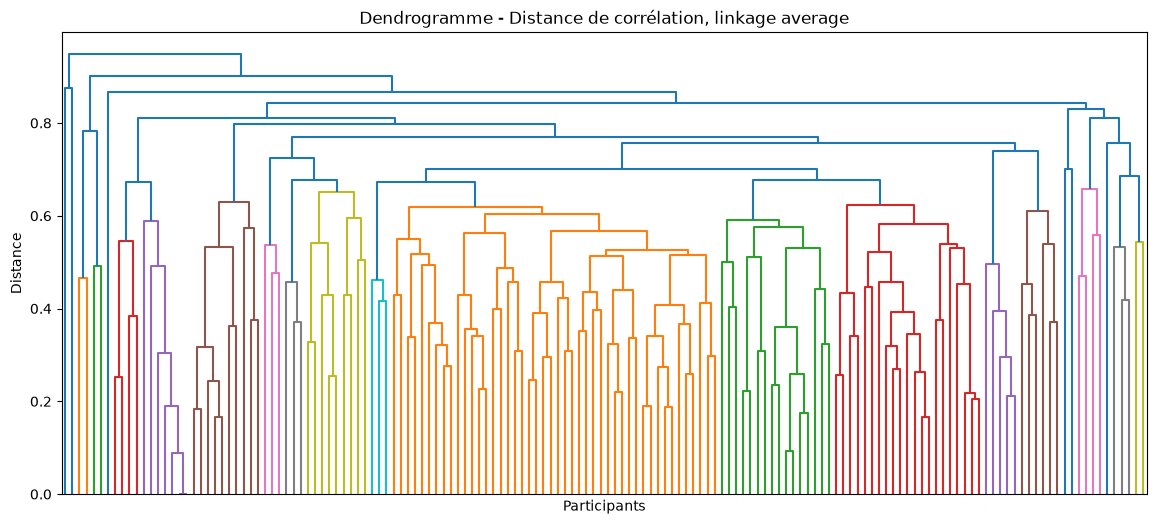

k=2: silhouette = 0.199
k=3: silhouette = 0.128
k=4: silhouette = 0.074
k=5: silhouette = 0.000
k=6: silhouette = 0.004
k=7: silhouette = -0.006
k=8: silhouette = -0.017
k=9: silhouette = -0.000
k=10: silhouette = 0.014


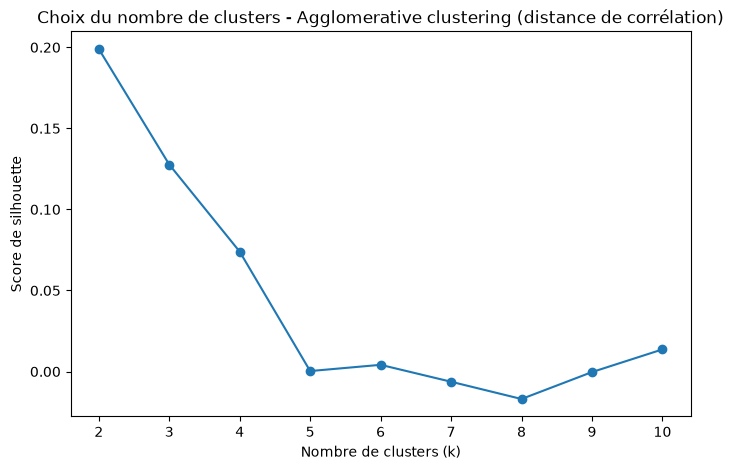


Meilleur k selon le score de silhouette : 2
Score de silhouette : 0.199


cluster
0    150
1      2
Name: count, dtype: int64

In [21]:
import numpy as np

X = df_red[items].values

# --- Diagnostic avant de calculer la distance de corrélation ---
# La corrélation est indéfinie (NaN) pour un participant qui répond la même valeur à tous les items
# (variance nulle -> division par zéro), et pdist propage aussi tout NaN déjà présent dans X.
nan_par_ligne = np.isnan(X).sum(axis=1)
std_par_ligne = np.nanstd(X, axis=1)

masque_nan = nan_par_ligne > 0
masque_constant = std_par_ligne == 0
masque_a_exclure = masque_nan | masque_constant

print(f"Participants avec au moins une valeur manquante : {masque_nan.sum()}")
print(f"Participants avec un profil constant (variance nulle) : {masque_constant.sum()}")
print(f"Total exclu : {masque_a_exclure.sum()} / {X.shape[0]}")

df_red_clean = df_red.loc[~masque_a_exclure].reset_index(drop=True)
X = df_red_clean[items].values

# Matrice de distance = 1 - corrélation entre profils de participants
corr_dist = pdist(X, metric='correlation')
dist_matrix = squareform(corr_dist)

# Vérification finale : plus aucun NaN/Inf ne doit subsister
assert np.all(np.isfinite(corr_dist)), "Il reste des valeurs non finies dans corr_dist"

# Dendrogramme (linkage average, car ward n'accepte pas les distances précalculées)
Z = linkage(corr_dist, method='average')

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Dendrogramme - Distance de corrélation, linkage average")
plt.xlabel("Participants")
plt.ylabel("Distance")
plt.show()

# Test de plusieurs k avec le score de silhouette (sur la matrice de distance précalculée)
k_values = range(2, 11)
scores = []

for k in k_values:
    clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels = clustering.fit_predict(dist_matrix)
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    scores.append(score)
    print(f"k={k}: silhouette = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters - Agglomerative clustering (distance de corrélation)")
plt.xticks(list(k_values))
plt.show()

best_k = k_values[np.argmax(scores)]
print(f"\nMeilleur k selon le score de silhouette : {best_k}")
print(f"Score de silhouette : {max(scores):.3f}")

# Clustering final avec le k retenu (à ajuster si le dendrogramme suggère une autre coupe)
clustering_final = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage='average')
clusters = clustering_final.fit_predict(dist_matrix)

df_red_clean['cluster'] = clusters
df_red_clean['cluster'].value_counts()

# Bon on a aussi 2 clusters

# UMAP

In [ ]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red = df.drop(columns=colonnes_a_exclure)
len(df_red.columns)  # Vérifie le nombre de colonnes restantes
print(df_red.columns)

from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_red[items].values

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df.index]
custom_colors = ['#F6F926', '#A777F1'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants sains (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants sains (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
df_clust = df_red.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
for i, d in enumerate([df_cluster1, df_cluster2]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0    98
1    56
Name: count, dtype: int64
Cluster 0: 98 participants
Cluster 1: 56 participants


In [ ]:

clusters_list = [df_cluster1, df_cluster2]

variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

# 3. ton bloc resume
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

KeyError: 'score_total'